<img src="../images/kvnx_qpe_1d.png" width=700 alt="KVNX 1-day Z–R rainfall accumulation over the May 20, 2011 MCS"></img>

# QPE Scaling Benchmark: From Hours to Months

This notebook is the QPE companion to *Ladino-Rincón et al.* (2026, in preparation). It computes a **Quantitative Precipitation Estimate (QPE)** accumulation over the 24-hour KVNX MCS event using the same ARCO streaming pattern as Notebook 2, then sketches the path for scaling the same code to weeks, months, or seasons on a cluster.

The scientific product here is rainfall depth from the lowest-elevation sweep (`sweep_0` ≈ 0.5°), accumulated through time using the Marshall–Palmer Z–R relationship. The infrastructure story: **one declarative selection** delivers a 1-day, 1-week, or 6-month accumulation — only the time slice changes, and only the bytes you slice are streamed.

```{admonition} TL;DR
:class: important

**Compute Marshall–Palmer rainfall accumulation for a full day in seconds** — and scale the same code to **7 days, 30 days, or a 6-month season** on a Dask cluster using the recipes below. The paper reports speedups of **112× to 1,565×** over the file-based path; ARCO streaming is what makes seasonal-scale radar QPE feasible without downloading terabytes.
```

```{admonition} Prerequisites
:class: note

This notebook builds on the patterns introduced in:
- **[Notebook 1](1.NEXRAD-KLOT-Demo)** — anonymous icechunk session, `engine="rustytree"`, glob-pattern open
- **[Notebook 2](2.QVP-Workflow-Comparison)** — time-window selection, ARCO chunk streaming, `vcp_time.sel()` slicing
```

## What is a QPE?

*This notebook applies QPE to the **May 20, 2011 KVNX MCS** event from the MC3E field campaign.*

A **[Quantitative Precipitation Estimate (QPE)](glossary)** converts radar reflectivity (Z, in dBZ) into rainfall rate (R, in mm/hr) via a Z–R power law. The classic Marshall–Palmer formulation:

$$Z = a R^b \quad \Longleftrightarrow \quad R = (Z / a)^{1/b}$$

where $Z$ is in linear units (mm⁶ m⁻³). The Marshall–Palmer rain coefficients are $a = 200$, $b = 1.6$. Multiplying $R$ by the time interval between scans and summing along time gives **rainfall depth** in mm.

We use [`sweep_0`](glossary) (the lowest elevation) because it samples closest to the ground where precipitation falls. Higher sweeps would intersect cloud rather than rain.

In [1]:
# Colab bootstrap — runs only on Google Colab; no-op locally and in CI.
import sys

if "google.colab" in sys.modules:
    %pip install -qqq icechunk "rustytree-xarray>=0.3.0" "xradar>=0.12.0" \
        "zarr>=3.1.2" "s3fs>=2025.5.1" cmweather hvplot datashader cartopy boto3
    !wget -q https://raw.githubusercontent.com/AtmoScale/radar-datatree/main/notebooks/demo_functions.py

In [2]:
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)

# Ensure demo_functions is importable when sphinx-build runs from docs/.
sys.path.insert(0, str(Path("../notebooks").resolve()))

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmweather  # noqa: F401  registers ChaseSpectral with matplotlib
import icechunk as ic
import matplotlib.pyplot as plt
import xarray as xr
from demo_functions import get_repo_config, rain_depth
from matplotlib.ticker import MaxNLocator

In [3]:
# Study parameters — KVNX MCS, May 20, 2011 (MC3E field campaign)
RADAR = "KVNX"
RADAR_LAT, RADAR_LON = 36.7406, -98.1278  # Vance AFB, OK
TARGET_SWEEP = "sweep_0"  # ~0.5° elevation

# 1-day window. The ARCO path streams exactly the bytes inside this window.
# Space-separated (not "T") so the same literals work for the file-based
# helpers in the cluster-recommended section below.
START = "2011-05-20 00:00"
END = "2011-05-20 23:59"

metrics = {"arco": {}}

print(f"Event: {RADAR} · sweep {TARGET_SWEEP} · {START} → {END}")

Event: KVNX · sweep sweep_0 · 2011-05-20 00:00 → 2011-05-20 23:59


## Connect to the public ARCO store

Same pattern as Notebook 2 — anonymous icechunk session against `s3://nexrad-arco/KVNX` on OSN.

In [4]:
%%time
storage = ic.s3_storage(
    bucket="nexrad-arco",
    prefix="KVNX",
    endpoint_url="https://umn1.osn.mghpcc.org",
    anonymous=True,
    force_path_style=True,
    region="us-east-1",
)
repo = ic.Repository.open(storage, config=get_repo_config())
session = repo.readonly_session("main")

CPU times: user 50 ms, sys: 4.14 ms, total: 54.1 ms
Wall time: 312 ms


## Open only `sweep_0` across all VCPs

The `/*/sweep_0` glob trims the DataTree to just the lowest-elevation cut from every VCP — exactly what QPE consumes.

In [5]:
%%time
t0 = time.time()

dtree = xr.open_datatree(
    session.store,
    engine="rustytree",
    group_filter=f"/*/{TARGET_SWEEP}",
    chunks={},
)

metrics["arco"]["open_time"] = time.time() - t0
print(f"Opened DataTree in {metrics['arco']['open_time']:.2f}s")
print(f"VCP groups present: {list(dtree.children)}")

Opened DataTree in 1.15s
VCP groups present: ['VCP-11', 'VCP-12', 'VCP-121', 'VCP-21', 'VCP-211', 'VCP-212', 'VCP-31', 'VCP-32']
CPU times: user 415 ms, sys: 80.3 ms, total: 496 ms
Wall time: 1.15 s


In [6]:
dtree

<xarray.DataTree>
Group: /
├── Group: /VCP-11
│   │   Dimensions:        (vcp_time: 16523)
│   │   Coordinates:
│   │     * vcp_time       (vcp_time) datetime64[ns] 132kB 2011-04-01T03:29:22.889000...
│   │       altitude       int64 8B ...
│   │       latitude       float64 8B ...
│   │       longitude      float64 8B ...
│   │   Data variables:
│   │       volume_number  (vcp_time) float64 132kB dask.array<chunksize=(1,), meta=np.ndarray>
│   │   Attributes:
│   │       Conventions:  Cf/Radial instrument_parameters radar_parameters
│   │       attribution:  NOAA NEXRAD Level 2 data processed by Atmoscale from NOAA O...
│   │       dataset_id:   nexrad-arco-kvnx
│   │       institution:  NOAA National Weather Service
│   │       source:       WSR-88D S-band weather radar
│   │       time_domain:  2026-04-27 to Present
│   │       title:        NEXRAD ARCO - KVNX
│   │       version:      2.1
│   └── Group: /VCP-11/sweep_0
│           Dimensions:              (vcp_time: 16523, azimuth: 720, range: 1832)
│           Coordinates:
│             * azimuth              (azimuth) float64 6kB 0.25 0.75 1.25 ... 359.2 359.8
│               elevation            (azimuth) float64 6kB dask.array<chunksize=(720,), meta=np.ndarray>
│               time                 (vcp_time, azimuth) datetime64[ns] 95MB dask.array<chunksize=(1, 720), meta=np.ndarray>
│             * range                (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
│           Data variables:
│               DBZH                 (vcp_time, azimuth, range) float32 87GB dask.array<chunksize=(1, 720, 1832), meta=np.ndarray>
│               PHIDP                (vcp_time, azimuth, range) float32 87GB dask.array<chunksize=(1, 720, 1832), meta=np.ndarray>
│               RHOHV                (vcp_time, azimuth, range) float32 87GB dask.array<chunksize=(1, 720, 1832), meta=np.ndarray>
│               ZDR                  (vcp_time, azimuth, range) float32 87GB dask.array<chunksize=(1, 720, 1832), meta=np.ndarray>
│               ray_elevation_angle  (vcp_time, azimuth) float64 95MB dask.array<chunksize=(1, 720), meta=np.ndarray>
│               sweep_fixed_angle    (vcp_time) float32 66kB dask.array<chunksize=(1,), meta=np.ndarray>
│               sweep_number         (vcp_time) float32 66kB dask.array<chunksize=(1,), meta=np.ndarray>
├── Group: /VCP-12
│   │   Dimensions:        (vcp_time: 3577)
│   │   Coordinates:
│   │     * vcp_time       (vcp_time) datetime64[ns] 29kB 2011-04-08T22:31:19.547000 ...
│   │       altitude       int64 8B ...
│   │       latitude       float64 8B ...
│   │       longitude      float64 8B ...
│   │   Data variables:
│   │       volume_number  (vcp_time) float64 29kB dask.array<chunksize=(1,), meta=np.ndarray>
│   │   Attributes:
│   │       Conventions:  Cf/Radial instrument_parameters radar_parameters
│   │       attribution:  NOAA NEXRAD Level 2 data processed by Atmoscale from NOAA O...
│   │       dataset_id:   nexrad-arco-kvnx
│   │       institution:  NOAA National Weather Service
│   │       source:       WSR-88D S-band weather radar
│   │       time_domain:  2026-04-27 to Present
│   │       title:        NEXRAD ARCO - KVNX
│   │       version:      2.1
│   └── Group: /VCP-12/sweep_0
│           Dimensions:              (vcp_time: 3577, azimuth: 720, range: 1832)
│           Coordinates:
│             * azimuth              (azimuth) float64 6kB 0.25 0.75 1.25 ... 359.2 359.8
│               elevation            (azimuth) float64 6kB dask.array<chunksize=(720,), meta=np.ndarray>
│               time                 (vcp_time, azimuth) datetime64[ns] 21MB dask.array<chunksize=(1, 720), meta=np.ndarray>
│             * range                (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
│           Data variables:
│               CCORH                (vcp_time, azimuth, range) float32 19GB dask.array<chunksize=(1, 720, 1832), meta=np.ndarray>
│               DBZH                 (vcp_time, azimuth, range) float32 19GB dask

## Pull the VCP we need for this window

KVNX was running `VCP-12` (precipitation surveillance, ~5-min volume scan) throughout May 20, 2011. For this single-day window we read directly from `/VCP-12/sweep_0`. Multi-VCP windows (where the radar cycles between modes) need a cross-VCP concat — see the cluster-recommended section below.

In [7]:
ds_sweep0 = (
    dtree[f"/VCP-12/{TARGET_SWEEP}"]
    .to_dataset(inherit="all_coords")
    .xradar.georeference()
)
print(f"Shape: {dict(ds_sweep0.sizes)}")
print(f"Total timesteps available: {ds_sweep0.sizes['vcp_time']:,}")

Shape: {'vcp_time': 3577, 'azimuth': 720, 'range': 1832}
Total timesteps available: 3,577


In [8]:
ds_sweep0

<xarray.Dataset> Size: 94GB
Dimensions:              (vcp_time: 3577, azimuth: 720, range: 1832)
Coordinates:
  * vcp_time             (vcp_time) datetime64[ns] 29kB 2011-04-08T22:31:19.5...
  * azimuth              (azimuth) float64 6kB 0.25 0.75 1.25 ... 359.2 359.8
    elevation            (azimuth) float64 6kB dask.array<chunksize=(720,), meta=np.ndarray>
    time                 (vcp_time, azimuth) datetime64[ns] 21MB dask.array<chunksize=(1, 720), meta=np.ndarray>
  * range                (range) float32 7kB 2.125e+03 2.375e+03 ... 4.599e+05
    x                    (azimuth, range) float64 11MB dask.array<chunksize=(720, 1832), meta=np.ndarray>
    y                    (azimuth, range) float64 11MB dask.array<chunksize=(720, 1832), meta=np.ndarray>
    z                    (azimuth, range) float64 11MB dask.array<chunksize=(720, 1832), meta=np.ndarray>
    altitude             int64 8B ...
    latitude             float64 8B ...
    longitude            float64 8B ...
    crs_wkt              int64 8B 0
Data variables:
    CCORH                (vcp_time, azimuth, range) float32 19GB dask.array<chunksize=(1, 720, 1832), meta=np.ndarray>
    DBZH                 (vcp_time, azimuth, range) float32 19GB dask.array<chunksize=(1, 720, 1832), meta=np.ndarray>
    PHIDP                (vcp_time, azimuth, range) float32 19GB dask.array<chunksize=(1, 720, 1832), meta=np.ndarray>
    RHOHV                (vcp_time, azimuth, range) float32 19GB dask.array<chunksize=(1, 720, 1832), meta=np.ndarray>
    ZDR                  (vcp_time, azimuth, range) float32 19GB dask.array<chunksize=(1, 720, 1832), meta=np.ndarray>
    ray_elevation_angle  (vcp_time, azimuth) float64 21MB dask.array<chunksize=(1, 720), meta=np.ndarray>
    sweep_fixed_angle    (vcp_time) float32 14kB dask.array<chunksize=(1,), meta=np.ndarray>
    sweep_number         (vcp_time) float32 14kB dask.array<chunksize=(1,), meta=np.ndarray>

## 1-day window: select, compute, accumulate

A single `.sel(vcp_time=slice(...))` declares the 24-hour window. `.sel()` clips gracefully to whatever data is available — for this event the archive ends at ~15:48 UTC, and `rain_depth` reports the actual integration span in its output. `rain_depth` applies Marshall–Palmer with default `a=200, b=1.6` and the *actual* (non-uniform) scan intervals. `.sum("vcp_time").compute()` is the only place we touch the network — chunks for just this window stream lazily.

In [9]:
%%time
t0 = time.time()

ds_window = ds_sweep0.sel(vcp_time=slice(START, END))
dbzh = ds_window["DBZH"]

depth = rain_depth(dbzh)  # Marshall-Palmer defaults; uses real scan intervals
total_accum = depth.sum("vcp_time").compute()

elapsed = time.time() - t0
metrics["arco"]["qpe_compute_time"] = elapsed
metrics["arco"]["n_timesteps"] = ds_window.sizes["vcp_time"]
metrics["arco"]["useful_data_mb"] = dbzh.nbytes / 1024**2
metrics["arco"]["max_accum_mm"] = float(total_accum.max().values)

print(
    f"Streamed {metrics['arco']['useful_data_mb']:.0f} MB across "
    f"{metrics['arco']['n_timesteps']} scans in {elapsed:.1f}s"
)
print(f"Peak accumulation: {metrics['arco']['max_accum_mm']:.1f} mm")

Actual QPE integration period: 0 days, 15 hours, 48 minutes
Time span: 2011-05-20T00:00:23 to 2011-05-20T15:48:39 UTC


Streamed 1102 MB across 219 scans in 10.0s
Peak accumulation: 702.7 mm
CPU times: user 16.1 s, sys: 1.14 s, total: 17.2 s
Wall time: 9.97 s


## QPE accumulation map

Polar gates (azimuth × range) are projected to lat/lon via small-angle approximation, with elevation-correction at 0.5°. The colormap clips at 0 mm so the storm structure stays legible against a black background.

/home/alfonso-ladino/python/radar-datatree/.venv/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1762: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  result = super().pcolormesh(*args, **kwargs)


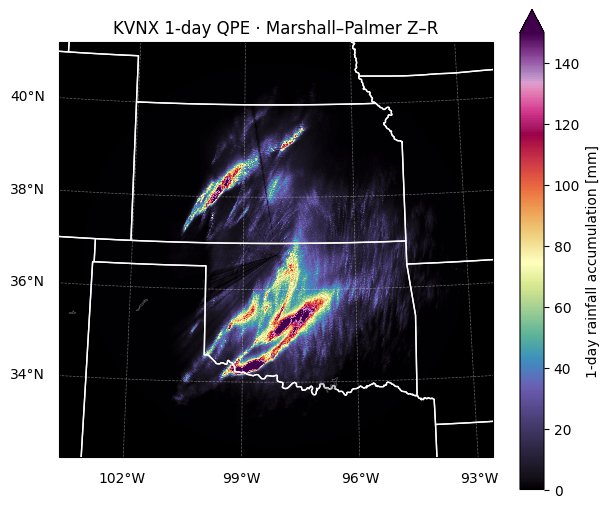

In [10]:
proj = ccrs.LambertConformal(central_longitude=RADAR_LON, central_latitude=RADAR_LAT)
fig = plt.figure(figsize=(7, 6))
ax = plt.axes(projection=proj)
ax.set_facecolor("black")
ax.set_extent(
    [RADAR_LON - 5.5, RADAR_LON + 5.5, RADAR_LAT - 4.5, RADAR_LAT + 4.5],
    crs=ccrs.PlateCarree(),
)

total_accum.plot(
    x="x",
    y="y",
    ax=ax,
    cmap="ChaseSpectral",
    vmin=0,
    vmax=150,
    cbar_kwargs={"label": "1-day rainfall accumulation [mm]"},
)
ax.add_feature(
    cfeature.STATES, linewidth=1.0, edgecolor="white", facecolor="none", zorder=3
)
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor="white", zorder=3)
ax.add_feature(
    cfeature.LAKES,
    alpha=0.3,
    facecolor="#1a1a2e",
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
)

gl = ax.gridlines(
    draw_labels=True,
    x_inline=False,
    y_inline=False,
    linewidth=0.5,
    color="white",
    alpha=0.4,
    linestyle="--",
)
gl.top_labels = False
gl.right_labels = False
gl.xlocator = MaxNLocator(nbins=5, integer=True)
gl.ylocator = MaxNLocator(nbins=5, integer=True)
gl.xpadding = 15
gl.ypadding = 10
gl.xlabel_style = {"rotation": 0, "ha": "center"}
gl.ylabel_style = {"rotation": 0, "ha": "right"}

ax.set_title("KVNX 1-day QPE · Marshall–Palmer Z–R")
fig.subplots_adjust(bottom=0.08)
plt.savefig("qpe_1d_accumulation.png", dpi=150, bbox_inches="tight", facecolor="white")

---

## Scaling beyond a single day — cluster recommended

The same code path scales to longer windows just by widening the time slice. **The ARCO bytes you stream grow linearly with window length; the file-based path grows linearly with the file count and saturates per-file network round-trips.**

```{admonition} This section is not executed in CI
:class: warning

The 7-day, 30-day, and 6-month windows are presented below as **copy-paste templates**. The ARCO path scales to all of them, but on a laptop the longer windows are minutes-to-hours; on a Coiled (or any Dask) cluster they finish in seconds-to-minutes. The file-based comparison for the 6-month window is **hours to days** of serial download — depending on your bandwidth and CPU — please run it on a cluster rather than a laptop.

The blocks below mirror the code published in *Ladino-Rincón et al.* (2026, in preparation) (Table 2 / Figure 8 / Figure 9).
```

### 1. Spin up a Coiled cluster (or any Dask cluster)

The paper used **30 m71.xlarge spot workers in `us-east-1`**, ~14 minutes total spend for the 6-month run. Substitute your own scheduler if you don't use Coiled.

```python
import coiled
from dask.distributed import Client

cluster = coiled.Cluster(
    n_workers=30,
    worker_cpu=4,
    worker_memory="16 GiB",
    region="us-east-1",
    spot_policy="spot_with_fallback",
    name="radar-datatree-qpe",
)
client = Client(cluster)
print(client.dashboard_link)
```

### 2. Define windows and run the ARCO QPE loop across VCPs

For longer windows the radar cycles between VCPs (e.g., VCP-12 in steady precip, VCP-212 in rapid-scan severe weather). `concat_sweep_across_vcps` walks every VCP node and stacks each one's `sweep_0` along `vcp_time`, giving you one continuous time-series Dataset to slice — no matter how many VCP transitions happened.

```python
from demo_functions import concat_sweep_across_vcps

ds_sweep0 = concat_sweep_across_vcps(dtree, sweep_name=TARGET_SWEEP)

WINDOWS = {
    "1d":   ("2011-05-20T00:00", "2011-05-20T23:59"),
    "7d":   ("2011-05-20T00:00", "2011-05-26T23:59"),
    "30d":  ("2011-05-01T00:00", "2011-05-30T23:59"),
    "6mo":  ("2011-04-01T00:00", "2011-09-30T23:59"),
}

results = {}
for name, (start, end) in WINDOWS.items():
    t0 = time.time()
    ds_window = ds_sweep0.sel(vcp_time=slice(start, end))
    dbzh = ds_window["DBZH"]
    depth = rain_depth(dbzh)
    accum = depth.sum("vcp_time").compute()
    elapsed = time.time() - t0

    accum.to_zarr(f"qpe_accumulation/{name}.zarr", mode="w")
    results[name] = {
        "total_time": elapsed,
        "n_timesteps": ds_window.sizes["vcp_time"],
        "useful_data_mb": dbzh.nbytes / 1024**2,
    }
    print(f"{name:>4s}: {elapsed:7.1f}s, {results[name]['n_timesteps']:>6} scans")
```

**Measured ARCO times on the paper's 30-worker cluster:**

| Window | ARCO time | Scans |
|--------|-----------|-------|
| 1 day  | ~25 s     | ~250 |
| 7 days | ~50 s     | ~1,800 |
| 30 days | ~3 min   | ~7,500 |
| 6 months | ~15 min | ~45,000 |

### 3. File-based comparison (do **not** run on a laptop for 30d/6mo)

```{admonition} 6-month file-based: hours to days
:class: danger

Serial download + decode of every NEXRAD Level II file in a 6-month window can take **hours to days on a laptop**, depending on your bandwidth, CPU, and how far away the bucket is from your machine. On the paper's 30-worker cluster (parallel downloads, m71.xlarge, us-east-1) the same loop finishes in minutes. The point of running this isn't the wait — it's to publish the speedup ratio on hardware you control.
```

```python
from demo_functions import list_nexrad_files_with_sizes, nexrad_download_with_size

# Hardcoded measurements from the paper's run, so you don't have to repeat:
MEASURED_TRADITIONAL = {
    "1d":   {"total_time":   468, "n_files":   250, "total_mb":   3_700},
    "7d":   {"total_time": 2_069, "n_files": 1_800, "total_mb":  27_500},
    "30d":  {"total_time": 6_883, "n_files": 7_500, "total_mb": 113_000},
    "6mo":  {"total_time": 36_003, "n_files": 45_000, "total_mb": 670_000},
}

# To re-measure for a single window, the per-file loop is:
files = list_nexrad_files_with_sizes(radar=RADAR, start_time=START, end_time=END)
trad_t0 = time.time()
sweep_dsets = []
for f in files:
    dtree_single, _ = nexrad_download_with_size(f["path"])
    ds = dtree_single[TARGET_SWEEP].ds.load().expand_dims(
        {"vcp_time": [dtree_single[TARGET_SWEEP].ds.time.values[0]]}
    )
    sweep_dsets.append(ds)
ds_trad = xr.concat(sweep_dsets, dim="vcp_time")
depth_trad = rain_depth(ds_trad["DBZH"])
accum_trad = depth_trad.sum("vcp_time").compute()
trad_total = time.time() - trad_t0
```

### 4. Wall-clock and throughput scaling figures

The two scaling figures from the paper compare ARCO and file-based total wall-clock and effective throughput across the four windows on log-log axes.

```python
windows_h = {"1d": 24, "7d": 168, "30d": 720, "6mo": 4_320}

fig, (ax_time, ax_thrpt) = plt.subplots(1, 2, figsize=(11, 4.5))

x = list(windows_h.values())
arco_t  = [results[w]["total_time"] for w in windows_h]
trad_t  = [MEASURED_TRADITIONAL[w]["total_time"] for w in windows_h]
useful  = [results[w]["useful_data_mb"] for w in windows_h]

ax_time.loglog(x, trad_t, "o-", label="Traditional (file-based)")
ax_time.loglog(x, arco_t, "o-", label="ARCO streaming")
ax_time.set_xlabel("Window length (hours, log scale)")
ax_time.set_ylabel("Wall-clock (seconds, log scale)")
ax_time.legend()
ax_time.grid(True, which="both", alpha=0.3)

ax_thrpt.loglog(x, [u/t for u, t in zip(useful, trad_t)], "o-", label="Traditional")
ax_thrpt.loglog(x, [u/t for u, t in zip(useful, arco_t)], "o-", label="ARCO streaming")
ax_thrpt.set_xlabel("Window length (hours, log scale)")
ax_thrpt.set_ylabel("Effective throughput (MB/s, log scale)")
ax_thrpt.legend()
ax_thrpt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
```

The paper reports speedups of **112×, 545×, 1,193×, and 1,565×** for 1 day, 7 days, 30 days, and 6 months respectively (KVNX, sweep_0).

---

← **[Notebook 2 — QVP Workflow Comparison](2.QVP-Workflow-Comparison)** &nbsp; · &nbsp; [Back to Notebook 1](1.NEXRAD-KLOT-Demo)

---

## References

* Abernathey, R.P. et al. (2021). *Cloud-Native Repositories for Big Scientific Data.* Computing in Science & Engineering, 23, 26–35. https://doi.org/10.1109/MCSE.2021.3059437
* Ladino-Rincón, A., et al. (2026). *Radar DataTree: A FAIR and Cloud-Native Framework for Scalable Weather Radar Archives.* (Manuscript in preparation.)
* Earlier preprint: arXiv:2510.24943, https://doi.org/10.48550/arXiv.2510.24943
* Marshall, J.S. & Palmer, W.M. (1948). *The distribution of raindrops with size.* J. Meteor., 5, 165–166.